In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# Загрузка данных

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
from torchvision.datasets import CIFAR10

data_train = CIFAR10('./', download = True, train = True, transform=transform)
data_test = CIFAR10('./', download = True, train = False, transform=transform)

100%|██████████| 170M/170M [00:03<00:00, 48.4MB/s]


In [ ]:
train_loader = DataLoader(data_train, batch_size=10, shuffle=True)
test_loader = DataLoader(data_test, batch_size=10, shuffle=False)
train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

In [ ]:
train_images.shape

torch.Size([10, 3, 32, 32])

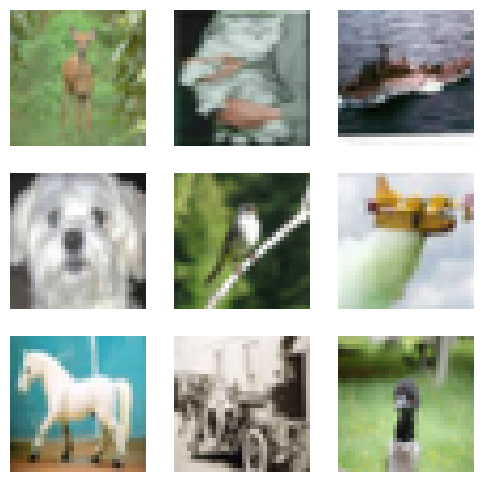

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(6, 6))
axs = axs.flatten()
for i, ax in enumerate(axs):
  ax.axis('off')
  train_image_np = train_images[i].numpy()
  train_image_np = np.transpose(train_image_np, (1, 2, 0))
  ax.imshow(train_image_np)
plt.show()

# Создание сети LeNet со старой архитектурой

In [ ]:
from torch import optim

lenet_old = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0),
    nn.Tanh(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
    nn.Tanh(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0),
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(in_features=120, out_features=84),
    nn.Tanh(),
    nn.Linear(in_features=84, out_features=10)
)

In [ ]:
lenet_relu = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=120, out_features=84),
    nn.ReLU(),
    nn.Linear(in_features=84, out_features=10)
)

In [ ]:
lenet_maxpool = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=120, out_features=84),
    nn.ReLU(),
    nn.Linear(in_features=84, out_features=10)
)

# Создание сети LeNet с новой архитектурой

In [ ]:
lenet_new = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=0),
    nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3, stride=1, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding=0),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=120, out_features=84),
    nn.ReLU(),
    nn.Linear(in_features=84, out_features=10)
)

In [ ]:
lenet_new_batchnorm = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=0),
    nn.BatchNorm2d(6),
    nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3, stride=1, padding=0),
    nn.BatchNorm2d(6),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding=0),
    nn.BatchNorm2d(16),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=0),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0),
    nn.BatchNorm2d(120),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(in_features=120, out_features=84),
    nn.Linear(in_features=84, out_features=10)
)

In [ ]:
def train_model(model, train_loader, test_loader, num_epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    test_losses = []
    for epoch in range(num_epochs):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                total_loss += criterion(output, target).item()
        total_loss /= len(test_loader.dataset)
        print(f'Эпоха {epoch+1}, Ошибка на тестовом наборе: {total_loss}')
        test_losses.append(total_loss)
    return test_losses

In [ ]:
loss_vals = {}

In [ ]:
loss_vals['Old'] =  train_model(lenet_old, train_loader, test_loader)

Эпоха 1, Ошибка на тестовом наборе: 0.15262327679395676
Эпоха 2, Ошибка на тестовом наборе: 0.14238179186582564
Эпоха 3, Ошибка на тестовом наборе: 0.1391057762980461
Эпоха 4, Ошибка на тестовом наборе: 0.13459537895917892
Эпоха 5, Ошибка на тестовом наборе: 0.13334551107883452
Эпоха 6, Ошибка на тестовом наборе: 0.13773590847849845
Эпоха 7, Ошибка на тестовом наборе: 0.13116134967505932
Эпоха 8, Ошибка на тестовом наборе: 0.1317475148141384
Эпоха 9, Ошибка на тестовом наборе: 0.1309957578599453
Эпоха 10, Ошибка на тестовом наборе: 0.13189640175104142


In [ ]:
loss_vals['ReLU'] =  train_model(lenet_relu, train_loader, test_loader)

Эпоха 1, Ошибка на тестовом наборе: 0.14676431342959403
Эпоха 2, Ошибка на тестовом наборе: 0.13503098185360432
Эпоха 3, Ошибка на тестовом наборе: 0.1305059120953083
Эпоха 4, Ошибка на тестовом наборе: 0.1250248824685812
Эпоха 5, Ошибка на тестовом наборе: 0.12196732598543167
Эпоха 6, Ошибка на тестовом наборе: 0.12018203500509263
Эпоха 7, Ошибка на тестовом наборе: 0.12134841790944338
Эпоха 8, Ошибка на тестовом наборе: 0.12362976595163346
Эпоха 9, Ошибка на тестовом наборе: 0.11938656135350466
Эпоха 10, Ошибка на тестовом наборе: 0.12163427246063947


In [ ]:
loss_vals['MaxPool'] = train_model(lenet_maxpool, train_loader, test_loader)

Эпоха 1, Ошибка на тестовом наборе: 0.14530886880755425
Эпоха 2, Ошибка на тестовом наборе: 0.130761710524559
Эпоха 3, Ошибка на тестовом наборе: 0.1279850322186947
Эпоха 4, Ошибка на тестовом наборе: 0.12635223287940026
Эпоха 5, Ошибка на тестовом наборе: 0.11973529007434845
Эпоха 6, Ошибка на тестовом наборе: 0.11904758349359036
Эпоха 7, Ошибка на тестовом наборе: 0.12038351429998875
Эпоха 8, Ошибка на тестовом наборе: 0.121156927344203
Эпоха 9, Ошибка на тестовом наборе: 0.12163417031764984
Эпоха 10, Ошибка на тестовом наборе: 0.11665075269639492


In [ ]:
loss_vals['New'] = train_model(lenet_new, train_loader, test_loader)

Эпоха 1, Ошибка на тестовом наборе: 0.10533058680221438
Эпоха 2, Ошибка на тестовом наборе: 0.10610760502964259
Эпоха 3, Ошибка на тестовом наборе: 0.10428788038268685
Эпоха 4, Ошибка на тестовом наборе: 0.11102690882459283
Эпоха 5, Ошибка на тестовом наборе: 0.10693822467587888
Эпоха 6, Ошибка на тестовом наборе: 0.10899268716797232
Эпоха 7, Ошибка на тестовом наборе: 0.11708532604537904
Эпоха 8, Ошибка на тестовом наборе: 0.11501861137468368
Эпоха 9, Ошибка на тестовом наборе: 0.11513315542042256
Эпоха 10, Ошибка на тестовом наборе: 0.11221486383490265


In [ ]:
loss_vals['New_Batch_norm'] = train_model(lenet_new_batchnorm, train_loader, test_loader)

Эпоха 1, Ошибка на тестовом наборе: 0.12044749368727208
Эпоха 2, Ошибка на тестовом наборе: 0.10864159486293792
Эпоха 3, Ошибка на тестовом наборе: 0.10360713776051998
Эпоха 4, Ошибка на тестовом наборе: 0.10240897289812564
Эпоха 5, Ошибка на тестовом наборе: 0.09937747398912906
Эпоха 6, Ошибка на тестовом наборе: 0.09527463449537754
Эпоха 7, Ошибка на тестовом наборе: 0.09456083092987537
Эпоха 8, Ошибка на тестовом наборе: 0.09393964169174433
Эпоха 9, Ошибка на тестовом наборе: 0.09163912460952997
Эпоха 10, Ошибка на тестовом наборе: 0.09327562332451343


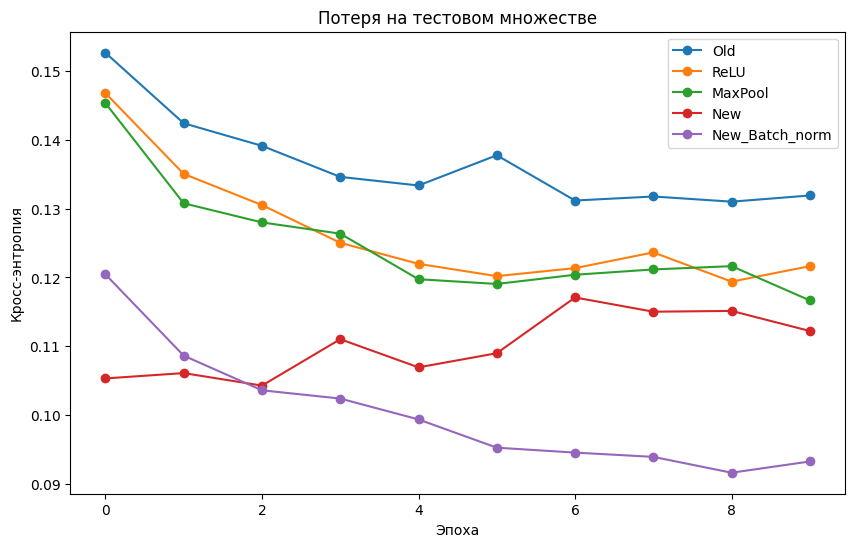

In [ ]:
plt.figure(figsize=(10, 6))
for lenet in loss_vals.keys():
  plt.plot(loss_vals[lenet], label=lenet, marker='o')
plt.xlabel("Эпоха")
plt.ylabel("Кросс-энтропия")
plt.title("Потеря на тестовом множестве")
plt.legend()
plt.show()